In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  str    
 7   marital_status        593994 non-null  str    
 8   education_level       593994 non-null  str    
 9   employment_status     593994 non-null  str    
 10  loan_purpose          593994 non-null  str    
 11  grade_subgrade        593994 non-null  str    
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), str(6)
memory usage: 84.0 MB


In [ ]:
# Detecting missing data
missing_data = df_test.isnull().sum()
missing_percent = (df_test.isnull().sum() / len(df_test)) * 100

print(missing_data)
print(missing_percent)

id                      0
annual_income           0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
interest_rate           0
gender                  0
marital_status          0
education_level         0
employment_status       0
loan_purpose            0
grade_subgrade          0
dtype: int64
id                      0.0
annual_income           0.0
debt_to_income_ratio    0.0
credit_score            0.0
loan_amount             0.0
interest_rate           0.0
gender                  0.0
marital_status          0.0
education_level         0.0
employment_status       0.0
loan_purpose            0.0
grade_subgrade          0.0
dtype: float64


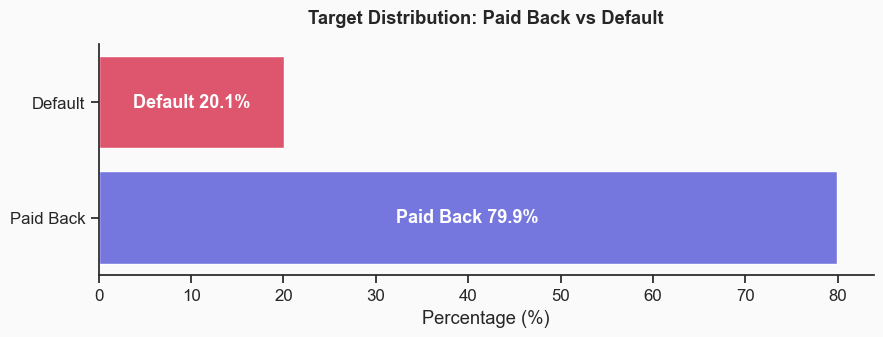

In [30]:
sns.set_context("notebook", font_scale=1.1)
sns.set_style("ticks", {"axes.facecolor": ".98"})
plt.rcParams['figure.facecolor'] = '.98'

modern_palette = ['#f43f5e', '#6366f1'] 
main_color = '#6366f1'
sns.set_palette(modern_palette)

plt.figure(figsize=(10, 3))
target_counts = df_train['loan_paid_back'].value_counts()
target_pct = (target_counts / len(df_train) * 100).round(1)
x_vals = [target_pct[0.0], target_pct[1.0]]
y_labels = ['Default', 'Paid Back']
ax = sns.barplot(x=x_vals, y=y_labels, hue=y_labels, palette=modern_palette, orient='h', legend=False)
plt.title('Target Distribution: Paid Back vs Default', fontweight='bold', pad=15)
plt.xlabel('Percentage (%)')

sns.despine()

for i, v in enumerate(x_vals):
    ax.text(v / 2, i, f'{y_labels[i]} {v}%', color='white', ha='center', va='center', fontweight='bold', fontsize=13)
plt.show()

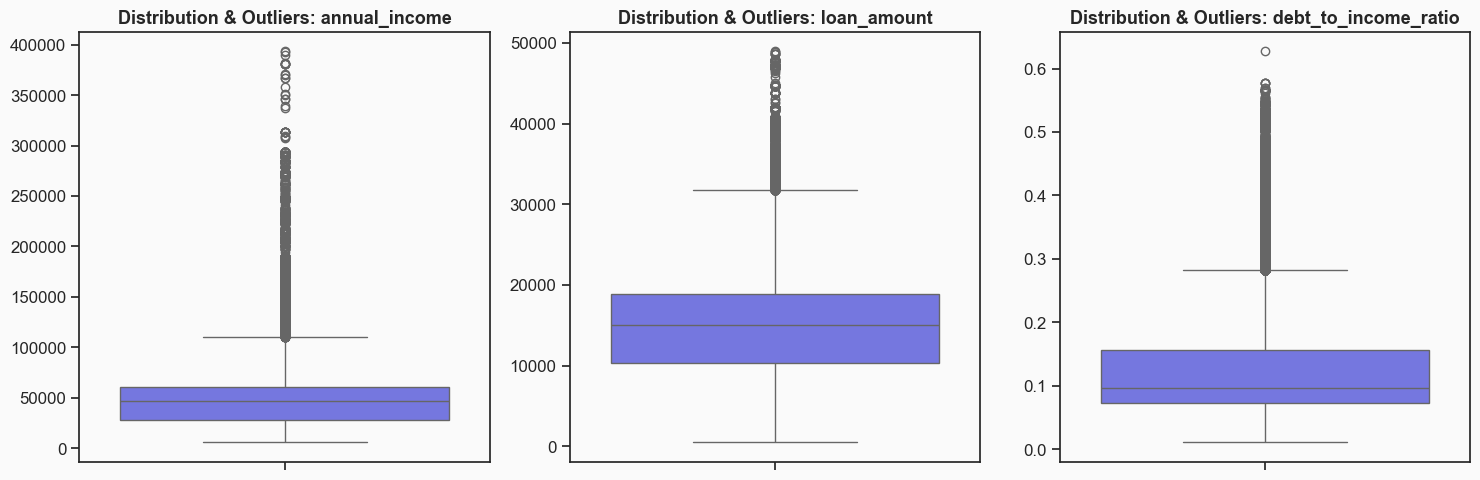

In [35]:
# Detecting outliers

cols_to_check = ['annual_income', 'loan_amount', 'debt_to_income_ratio']
plt.figure(figsize=(15,5))
for i, col in enumerate(cols_to_check, 1):
    plt.subplot(1, 3, i)
    
    sns.boxplot(y=df_train[col], color=main_color)
    
    plt.title(f'Distribution & Outliers: {col}', fontsize=13, fontweight='bold')
    plt.ylabel('')
    
plt.tight_layout()
plt.show()

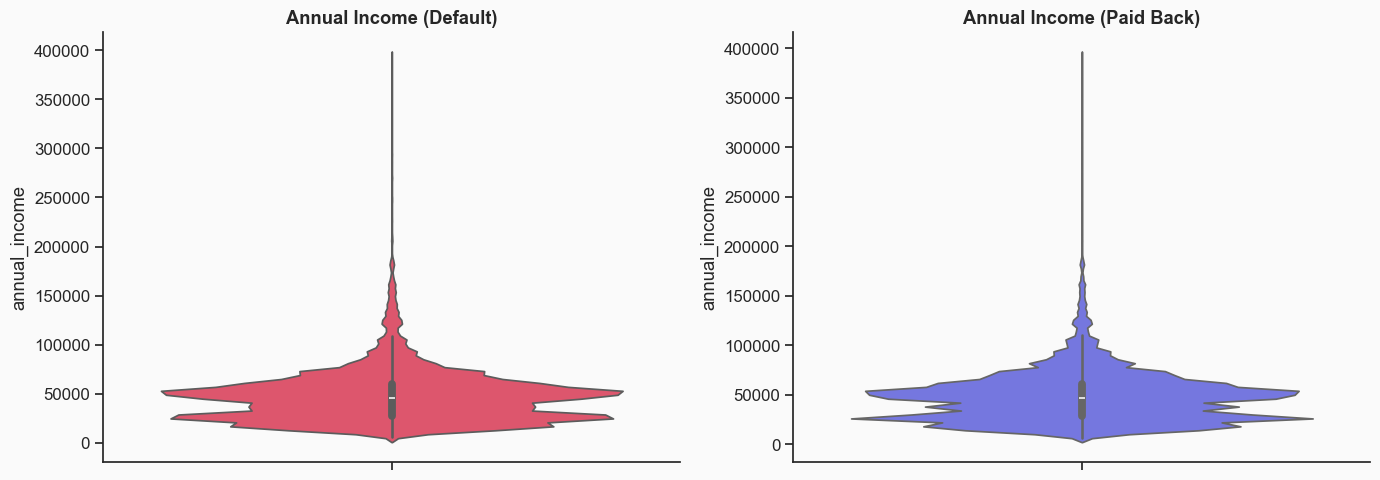

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.violinplot(data=df_train[df_train['loan_paid_back'] == 0.0], y='annual_income', color=modern_palette[0], ax=axes[0])
axes[0].set_title('Annual Income (Default)', fontweight='bold')
sns.despine(ax=axes[0])
sns.violinplot(data=df_train[df_train['loan_paid_back'] == 1.0], y='annual_income', color=modern_palette[1], ax=axes[1])
axes[1].set_title('Annual Income (Paid Back)', fontweight='bold')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

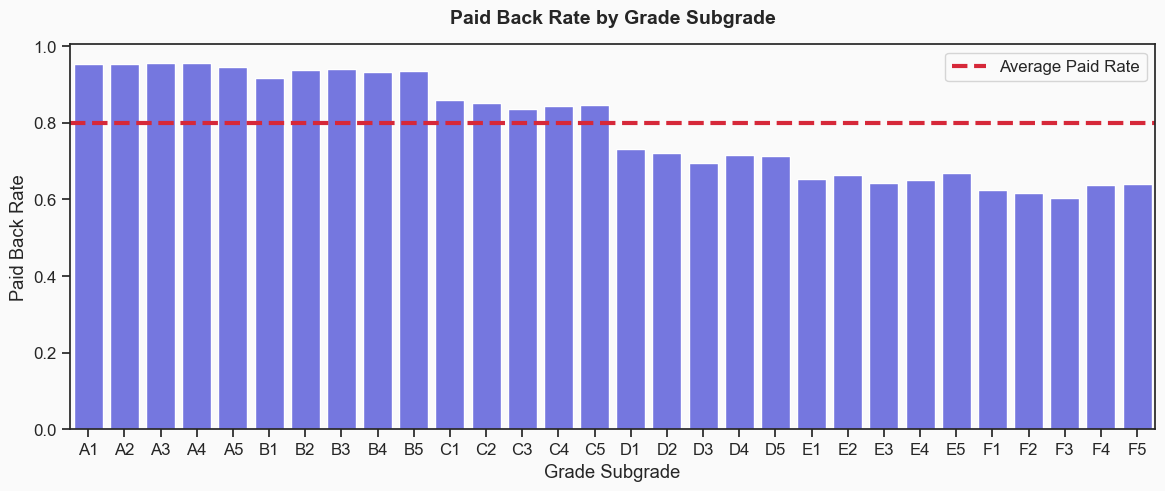

In [33]:
plt.figure(figsize=(14, 5))
grade_order = sorted(df_train['grade_subgrade'].unique())

sns.barplot(data=df_train, x='grade_subgrade', y='loan_paid_back', order=grade_order, errorbar=None, color=main_color)

plt.axhline(df_train['loan_paid_back'].mean(), color=custom_palette[0], linestyle='--', linewidth=3, label='Average Paid Rate')
plt.title('Paid Back Rate by Grade Subgrade', fontsize=14, fontweight='bold', pad=15)

plt.ylabel('Paid Back Rate')
plt.xlabel('Grade Subgrade')
plt.legend()
plt.show()

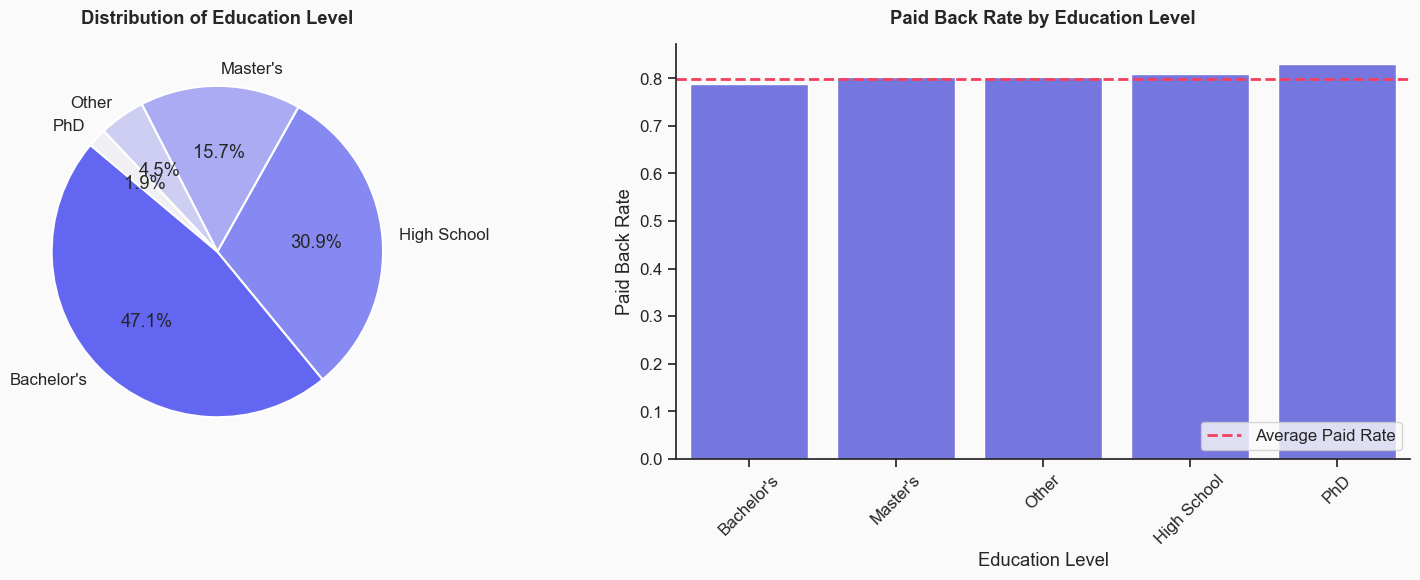

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

edu_counts = df_train['education_level'].value_counts()
colors_pie = sns.color_palette("light:#6366f1_r", len(edu_counts)) 
axes[0].pie(edu_counts, labels=edu_counts.index, autopct='%1.1f%%', startangle=140, 
            colors=colors_pie, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Distribution of Education Level', fontweight='bold', pad=15)

edu_stats = df_train.groupby('education_level')['loan_paid_back'].mean().sort_values().reset_index()
sns.barplot(data=edu_stats, x='education_level', y='loan_paid_back', color=main_color, ax=axes[1])
axes[1].axhline(df_train['loan_paid_back'].mean(), color=modern_palette[0], linestyle='--', linewidth=2, label='Average Paid Rate')
axes[1].set_title('Paid Back Rate by Education Level', fontweight='bold', pad=15)
axes[1].set_ylabel('Paid Back Rate')
axes[1].set_xlabel('Education Level')
axes[1].tick_params(axis='x', rotation=45) 
axes[1].legend(loc='lower right')
sns.despine(ax=axes[1])

plt.tight_layout()
plt.show()

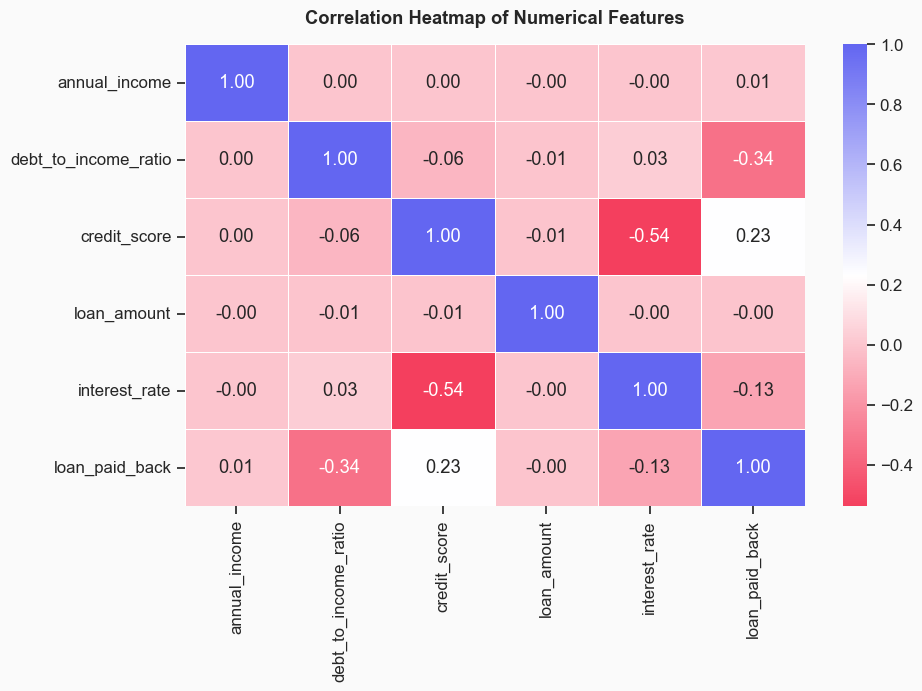

In [31]:
plt.figure(figsize=(10, 6))
num_cols = df_train.select_dtypes(include=[np.number]).columns.drop('id', errors='ignore')

custom_cmap = sns.blend_palette(['#f43f5e', 'white', '#6366f1'], as_cmap=True)
sns.heatmap(df_train[num_cols].corr(), annot=True, cmap=custom_cmap, fmt=".2f", linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features', fontweight='bold', pad=15)
plt.show()

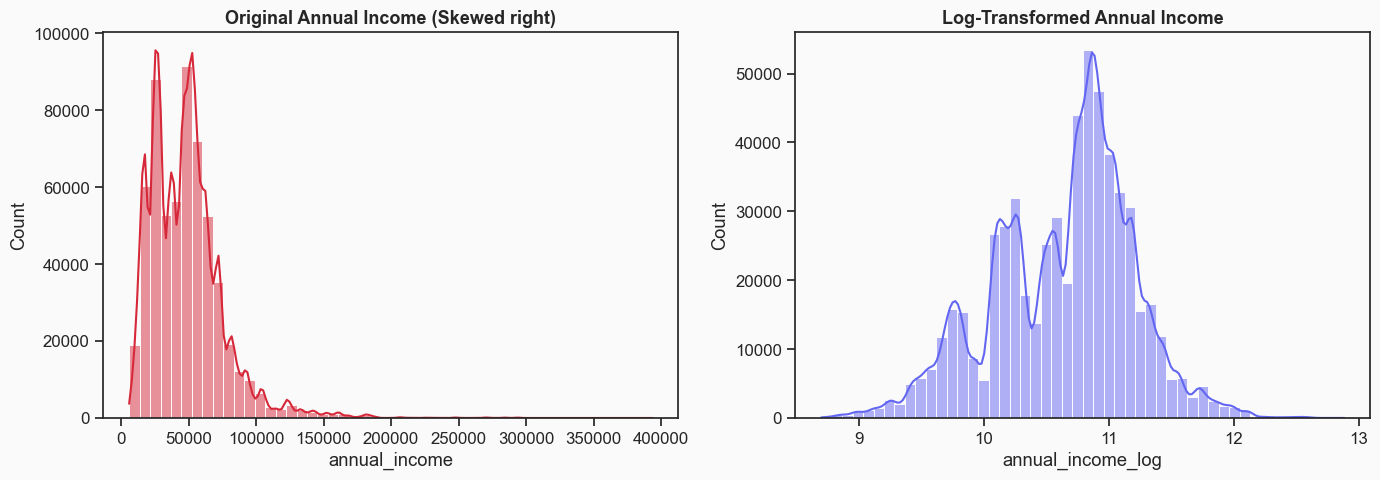

In [36]:
# Feature Engineering

train_clean = df_train.copy()
test_clean = df_test.copy()

# Log Transformation (for annual_income)
train_clean['annual_income_log'] = np.log1p(train_clean['annual_income'])
test_clean['annual_income_log'] = np.log1p(test_clean['annual_income'])

# Winsorization (for debt-to-income-ratio)
dti_99th_percentile = train_clean['debt_to_income_ratio'].quantile(0.99)

train_clean['debt_to_income_ratio_capped'] = np.where(
    train_clean['debt_to_income_ratio'] > dti_99th_percentile, dti_99th_percentile, 
    train_clean['debt_to_income_ratio']
)

test_clean['debt_to_income_ratio_capped'] = np.where(
    test_clean['debt_to_income_ratio'] > dti_99th_percentile, 
    dti_99th_percentile, 
    test_clean['debt_to_income_ratio']
)

# Results after process of feature engineering
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_clean['annual_income'], bins=50, kde=True, color=custom_palette[0], ax=axes[0])
axes[0].set_title('Original Annual Income (Skewed right)', fontsize=13, fontweight='bold')

sns.histplot(train_clean['annual_income_log'], bins=50, kde=True, color=main_color, ax=axes[1])
axes[1].set_title('Log-Transformed Annual Income', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


In [37]:
# Save cleaned data to .csv files

train_clean.to_csv('../data/train_clean.csv', index=False)
test_clean.to_csv('../data/test_clean.csv', index=False)

print("Exported data successfully!")

Exported data successfully!
